In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson

Probabilità p: 0.1
Valore atteso (mu): 100.0
Deviazione std (sigma): 9.49


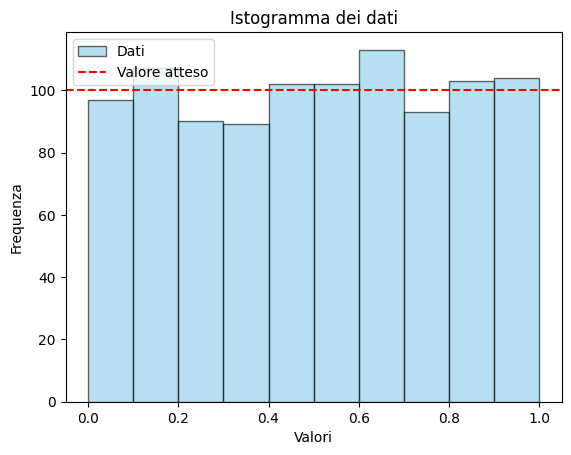

In [20]:
# Punto 1 - Istogramma 
N=1000
n_bins = 10

dati = np.random.uniform(0, 1, N)

p = 1/n_bins
mu = N * p
sigma = np.sqrt(N * p * (1 - p))


print(f"Probabilità p: {p}")
print(f"Valore atteso (mu): {mu}")
print(f"Deviazione std (sigma): {sigma:.2f}")

conteggi, bordi, _ = plt.hist(dati, bins=n_bins, range=(0, 1), color='skyblue', alpha=0.6, label='Dati', edgecolor='black')
plt.axhline(mu, color='red', linestyle='--', label='Valore atteso')
plt.xlabel('Valori')
plt.ylabel('Frequenza')
plt.title('Istogramma dei dati')
plt.legend()
plt.show()

In [41]:
M = 1000  
conteggi_bin = []

for i in range(M):
    dati_temp = np.random.uniform(0, 1, N)

    conteggi, _ = np.histogram(dati_temp, bins=n_bins, range=(0, 1))

    conteggi_bin.append(conteggi[4])


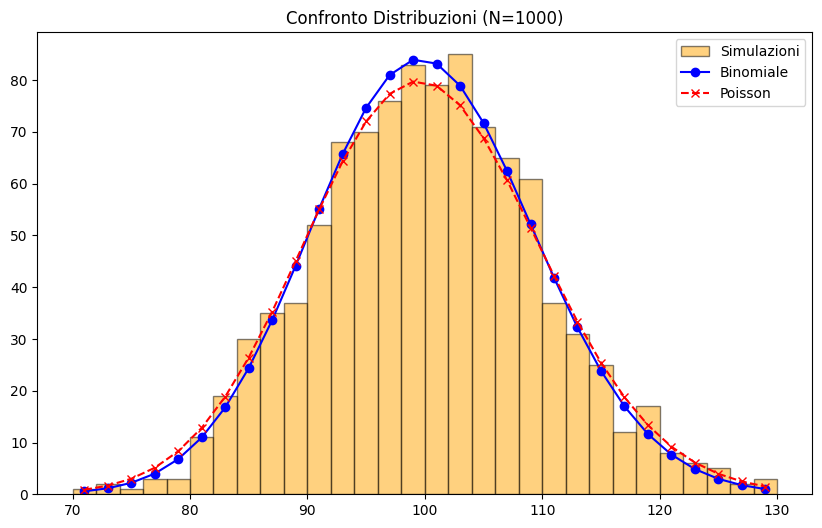

In [40]:
plt.figure(figsize=(10, 6))

h, bordi, _ = plt.hist(conteggi_bin, bins=30, range=(70, 130), alpha=0.5, color='orange', edgecolor='black', label='Simulazioni')

centri = (bordi[:-1] + bordi[1:]) / 2
delta_x = bordi[1] - bordi[0]


y_binom = binom.pmf(np.floor(centri), N, p) * M * delta_x 
plt.plot(centri, y_binom, 'b-o', label='Binomiale') 


lam = N * p
y_pois = poisson.pmf(np.floor(centri), lam) * M * delta_x
plt.plot(centri, y_pois, 'r--x', label='Poisson')

plt.legend()
plt.title(f'Confronto Distribuzioni (N={N})')
plt.show()

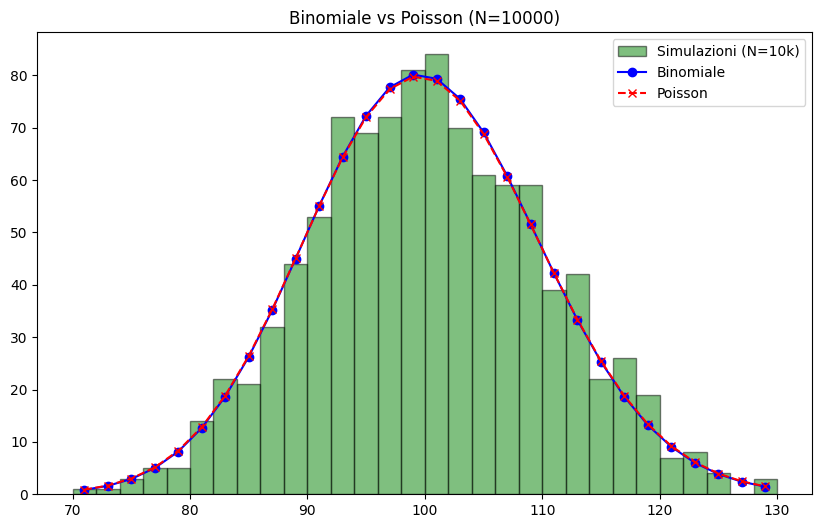

In [51]:
# Punto 5
N_2 = 10000
n_bins_2 = 100
p_2 = 1 / n_bins_2

conteggi_2 = []

for i in range(M):
    dati_temporanei = np.random.uniform(0, 1, N_2)
    conteggi_temp, _ = np.histogram(dati_temporanei, bins=n_bins_2, range=(0, 1))
    conteggi_2.append(conteggi_temp[50])

plt.figure(figsize=(10, 6))

h, bordi, _ = plt.hist(conteggi_2, bins=30, range=(70, 130),
                       alpha=0.5, color='green', edgecolor='black', label='Simulazioni (N=10k)')

centri = (bordi[:-1] + bordi[1:]) / 2 
delta_x = bordi[1] - bordi[0] 

y_binom = binom.pmf(np.floor(centri), N_2, p_2) * M * delta_x
plt.plot(centri, y_binom, 'b-o', label='Binomiale')

lambda_2 = N_2 * p_2 
y_pois = poisson.pmf(np.floor(centri), lambda_2) * M * delta_x
plt.plot(centri, y_pois, 'r--x', label='Poisson')

plt.title('Binomiale vs Poisson (N=10000)')
plt.legend()
plt.show()